In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif

warnings.filterwarnings("ignore")

In [2]:
PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
FEATURE_DIR = DATA_DIR / "features"

RESULTS_DIR = PROJECT_DIR / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"

FEATURE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

features_path = FEATURE_DIR / "ptb_detection_handcrafted_features.csv"

print("Project directory:", PROJECT_DIR)
print("Feature file exists:", features_path.exists())

if not features_path.exists():
    raise FileNotFoundError("Feature file not found. Please run Notebook 4 first.")

Project directory: d:\HUST\ET4248E - Học máy trong y tế\Final Project
Feature file exists: True


In [3]:
PURPLE_MAIN = "#C599B6"
PURPLE_DARK = "#8A5A78"
PURPLE_MID = "#B77FA0"
PURPLE_LIGHT = "#E8D3DF"
PURPLE_VERY_LIGHT = "#F5EAF1"
GRAY = "#6B6B6B"
RED_SOFT = "#C44E52"

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [4]:
features_df = pd.read_csv(features_path)

print("Feature table shape:", features_df.shape)

display(features_df.head())

Feature table shape: (448, 1422)


,patient_id,record_id,record_path,mi_detected,healthy_control,reason_for_admission,extraction_status,error_message,fs,duration_sec,...,contrast_lateral_minus_chest_morph_qrs_ptp_mean,contrast_lateral_over_chest_morph_qrs_ptp_mean,contrast_lateral_minus_chest_morph_st_level_mean,contrast_lateral_over_chest_morph_st_level_mean,contrast_lateral_minus_chest_morph_t_amp_mean,contrast_lateral_over_chest_morph_t_amp_mean,contrast_lateral_minus_chest_ratio_abs_st_to_qrs,contrast_lateral_over_chest_ratio_abs_st_to_qrs,contrast_lateral_minus_chest_ratio_abs_t_to_qrs,contrast_lateral_over_chest_ratio_abs_t_to_qrs
0,patient001,s0010_re,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,1,0,Myocardial infarction,success,NaN,1000,38.4,...,-0.881952,0.869859,-0.113679,-1.232628,-0.277465,-1.848635,0.028838,1.397076,0.076624,1.332658
1,patient001,s0014lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,1,0,Myocardial infarction,success,NaN,1000,115.2,...,-0.547437,0.919469,-0.071970,-1.296162,-0.036523,0.432207,0.011147,1.290027,0.047875,1.497575
2,patient001,s0016lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,1,0,Myocardial infarction,success,NaN,1000,115.2,...,-0.581871,0.914905,-0.191350,-1.982390,0.611210,0.365668,0.019226,1.461171,0.034442,1.445004
3,patient002,s0015lre,ptb-diagnostic-ecg-database-1.0.0\patient002\s...,1,0,Myocardial infarction,success,NaN,1000,115.2,...,-0.045130,0.992804,-0.154674,-3.082995,0.024435,-0.989664,0.032816,3.750345,0.080275,1.202903
4,patient003,s0017lre,ptb-diagnostic-ecg-database-1.0.0\patient003\s...,1,0,Myocardial infarction,success,NaN,1000,115.2,...,1.033608,1.185153,-0.406936,-3.138080,-0.857880,0.563911,-0.032781,0.577757,-0.252801,0.530411


In [5]:
print("Extraction status counts:")
display(features_df["extraction_status"].value_counts())

failed_df = features_df[features_df["extraction_status"] != "success"].copy()

print("Number of failed records:", len(failed_df))

if len(failed_df) > 0:
    display(failed_df[["patient_id", "record_id", "error_message"]].head(20))

Extraction status counts:


extraction_status
success    448
Name: count, dtype: int64

Number of failed records: 0


In [6]:
print("Record-level class distribution:")
record_class_counts = features_df["mi_detected"].value_counts().sort_index()
display(record_class_counts)

print("\nPatient-level class distribution:")

patient_label_df = (
    features_df
    .groupby("patient_id")["mi_detected"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

patient_class_counts = patient_label_df["mi_detected"].value_counts().sort_index()
display(patient_class_counts)

print("\nLabel meaning:")
print("0 = Healthy Control")
print("1 = Myocardial Infarction")

Record-level class distribution:


mi_detected
0     80
1    368
Name: count, dtype: int64


Patient-level class distribution:


mi_detected
0     52
1    148
Name: count, dtype: int64


Label meaning:
0 = Healthy Control
1 = Myocardial Infarction


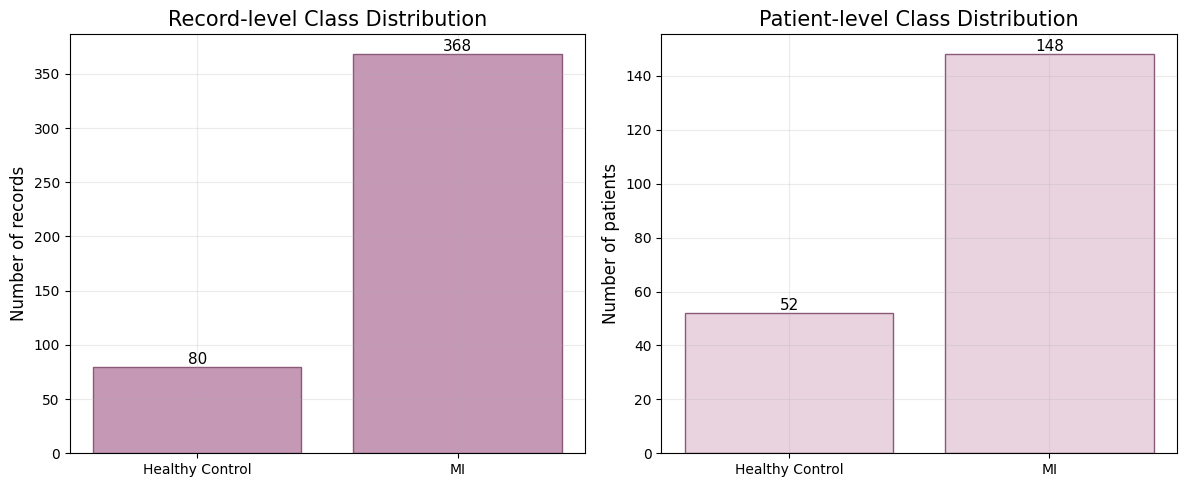

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook5_class_distribution_record_and_patient.png


In [7]:
fig_path = FIGURE_DIR / "notebook5_class_distribution_record_and_patient.png"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ["Healthy Control", "MI"]

axes[0].bar(
    labels,
    [record_class_counts.get(0, 0), record_class_counts.get(1, 0)],
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)
axes[0].set_title("Record-level Class Distribution")
axes[0].set_ylabel("Number of records")
axes[0].grid(axis="y", alpha=0.25)

for i, value in enumerate([record_class_counts.get(0, 0), record_class_counts.get(1, 0)]):
    axes[0].text(i, value, str(value), ha="center", va="bottom")

axes[1].bar(
    labels,
    [patient_class_counts.get(0, 0), patient_class_counts.get(1, 0)],
    color=PURPLE_LIGHT,
    edgecolor=PURPLE_DARK
)
axes[1].set_title("Patient-level Class Distribution")
axes[1].set_ylabel("Number of patients")
axes[1].grid(axis="y", alpha=0.25)

for i, value in enumerate([patient_class_counts.get(0, 0), patient_class_counts.get(1, 0)]):
    axes[1].text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

In [8]:
records_per_patient = (
    features_df
    .groupby("patient_id")
    .size()
    .rename("n_records")
    .reset_index()
)

print("Records per patient summary:")
display(records_per_patient["n_records"].describe())

display(records_per_patient.sort_values("n_records", ascending=False).head(10))

Records per patient summary:


count    200.000000
mean       2.240000
std        1.360757
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max        7.000000
Name: n_records, dtype: float64

,patient_id,n_records
137,patient180,7
4,patient005,5
92,patient093,5
156,patient233,5
16,patient017,4
6,patient007,4
29,patient030,4
32,patient033,4
48,patient049,4
49,patient050,4


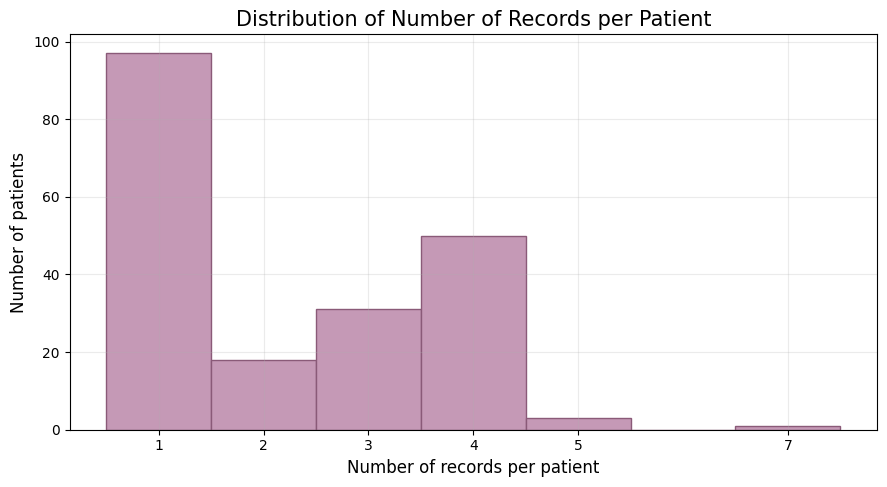

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook5_records_per_patient_distribution.png


In [9]:
fig_path = FIGURE_DIR / "notebook5_records_per_patient_distribution.png"

plt.figure(figsize=(9, 5))

bins = np.arange(
    records_per_patient["n_records"].min(),
    records_per_patient["n_records"].max() + 2
) - 0.5

plt.hist(
    records_per_patient["n_records"],
    bins=bins,
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.title("Distribution of Number of Records per Patient")
plt.xlabel("Number of records per patient")
plt.ylabel("Number of patients")
plt.xticks(sorted(records_per_patient["n_records"].unique()))
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

# Define feature columns for modeling

In [10]:
metadata_cols = [
    "patient_id",
    "record_id",
    "record_path",
    "reason_for_admission",
    "extraction_status",
    "error_message",
    "rpeak_detection_direction"
]

label_cols = [
    "mi_detected",
    "healthy_control"
]

quality_control_cols = [
    "fs",
    "duration_sec",
    "n_samples",
    "n_channels_original",
    "n_detected_rpeaks",
    "n_valid_beats",
    "beat_length_samples",
    "rhythm_n_detected_rpeaks",
    "rhythm_duration_sec"
]

exclude_cols = metadata_cols + label_cols + quality_control_cols

exclude_cols = [col for col in exclude_cols if col in features_df.columns]

model_feature_cols = [
    col for col in features_df.columns
    if col not in exclude_cols
]

print("Total columns:", features_df.shape[1])
print("Excluded columns:", len(exclude_cols))
print("Model feature columns:", len(model_feature_cols))

print("\nExcluded columns:")
print(exclude_cols)

print("\nFirst 30 model feature columns:")
print(model_feature_cols[:30])

Total columns: 1422
Excluded columns: 18
Model feature columns: 1404

Excluded columns:
['patient_id', 'record_id', 'record_path', 'reason_for_admission', 'extraction_status', 'error_message', 'rpeak_detection_direction', 'mi_detected', 'healthy_control', 'fs', 'duration_sec', 'n_samples', 'n_channels_original', 'n_detected_rpeaks', 'n_valid_beats', 'beat_length_samples', 'rhythm_n_detected_rpeaks', 'rhythm_duration_sec']

First 30 model feature columns:
['rhythm_hr_count', 'rhythm_hr_mean', 'rhythm_hr_median', 'rhythm_hr_std', 'rhythm_rr_mean', 'rhythm_rr_median', 'rhythm_rr_std', 'rhythm_rr_min', 'rhythm_rr_max', 'rhythm_rr_range', 'rhythm_rmssd', 'rhythm_pnn50', 'i_stat_mean', 'i_stat_median', 'i_stat_std', 'i_stat_var', 'i_stat_min', 'i_stat_max', 'i_stat_range', 'i_stat_rms', 'i_stat_energy', 'i_stat_abs_mean', 'i_stat_iqr', 'i_stat_skewness', 'i_stat_kurtosis', 'i_stat_entropy', 'i_stat_zcr', 'ii_stat_mean', 'ii_stat_median', 'ii_stat_std']


In [11]:
non_numeric_features = [
    col for col in model_feature_cols
    if not pd.api.types.is_numeric_dtype(features_df[col])
]

print("Number of non-numeric model features:", len(non_numeric_features))

if len(non_numeric_features) > 0:
    print(non_numeric_features)

numeric_model_feature_cols = [
    col for col in model_feature_cols
    if pd.api.types.is_numeric_dtype(features_df[col])
]

print("Numeric model feature columns:", len(numeric_model_feature_cols))

Number of non-numeric model features: 0
Numeric model feature columns: 1404


In [12]:
X_all = features_df[numeric_model_feature_cols].copy()

missing_values = X_all.isna().sum().sum()
infinite_values = np.isinf(X_all.to_numpy()).sum()

print("Model feature matrix shape:", X_all.shape)
print("Missing values:", missing_values)
print("Infinite values:", infinite_values)

if missing_values > 0:
    display(X_all.isna().sum().sort_values(ascending=False).head(20))

Model feature matrix shape: (448, 1404)
Missing values: 0
Infinite values: 0


In [ ]:
# CEll 13
lead_specific_stat_cols = []
lead_specific_morph_cols = []
lead_specific_ratio_cols = []
rhythm_cols = []
lead_group_cols = []
lead_contrast_cols = []
other_cols = []

for col in numeric_model_feature_cols:
    if col.startswith("rhythm_"):
        rhythm_cols.append(col)
    elif col.startswith("contrast_"):
        lead_contrast_cols.append(col)
    elif "_group_" in col:
        lead_group_cols.append(col)
    elif "_stat_" in col:
        lead_specific_stat_cols.append(col)
    elif "_morph_" in col:
        lead_specific_morph_cols.append(col)
    elif "_ratio_" in col:
        lead_specific_ratio_cols.append(col)
    else:
        other_cols.append(col)

feature_group_counts = pd.DataFrame({
    "feature_group": [
        "lead_specific_statistical",
        "lead_specific_morphology",
        "lead_specific_ratio",
        "rhythm",
        "lead_group",
        "lead_contrast",
        "other"
    ],
    "n_features": [
        len(lead_specific_stat_cols),
        len(lead_specific_morph_cols),
        len(lead_specific_ratio_cols),
        len(rhythm_cols),
        len(lead_group_cols),
        len(lead_contrast_cols),
        len(other_cols)
    ]
})

display(feature_group_counts)

print("Total model features counted:", feature_group_counts["n_features"].sum())
print("Numeric model feature columns:", len(numeric_model_feature_cols))

,feature_group,n_features
0,lead_specific_statistical,180
1,lead_specific_morphology,900
2,lead_specific_ratio,72
3,rhythm,12
4,lead_group,170
5,lead_contrast,70
6,other,0


Total model features counted: 1404
Numeric model feature columns: 1404


In [62]:
# Stronger filtering for normalization-derived statistical features

normalization_related_patterns = [
    "_stat_mean",
    "_stat_std",
    "_stat_var",
    "_stat_rms",
    "_stat_energy"
]

normalization_derived_cols = [
    col for col in numeric_model_feature_cols
    if any(pattern in col for pattern in normalization_related_patterns)
]

clean_model_feature_cols = [
    col for col in numeric_model_feature_cols
    if col not in normalization_derived_cols
]

print("Original model feature columns:", len(numeric_model_feature_cols))
print("Normalization-related statistical columns removed:", len(normalization_derived_cols))
print("Clean model feature columns:", len(clean_model_feature_cols))

print("\nExamples of removed columns:")
print(normalization_derived_cols[:40])

Original model feature columns: 1404
Normalization-related statistical columns removed: 100
Clean model feature columns: 1304

Examples of removed columns:
['i_stat_mean', 'i_stat_std', 'i_stat_var', 'i_stat_rms', 'i_stat_energy', 'ii_stat_mean', 'ii_stat_std', 'ii_stat_var', 'ii_stat_rms', 'ii_stat_energy', 'iii_stat_mean', 'iii_stat_std', 'iii_stat_var', 'iii_stat_rms', 'iii_stat_energy', 'avr_stat_mean', 'avr_stat_std', 'avr_stat_var', 'avr_stat_rms', 'avr_stat_energy', 'avl_stat_mean', 'avl_stat_std', 'avl_stat_var', 'avl_stat_rms', 'avl_stat_energy', 'avf_stat_mean', 'avf_stat_std', 'avf_stat_var', 'avf_stat_rms', 'avf_stat_energy', 'v1_stat_mean', 'v1_stat_std', 'v1_stat_var', 'v1_stat_rms', 'v1_stat_energy', 'v2_stat_mean', 'v2_stat_std', 'v2_stat_var', 'v2_stat_rms', 'v2_stat_energy']


# Feature EDA

In [63]:
eda_features = [
    "ii_stat_rms",
    "ii_stat_energy",
    "ii_morph_qrs_ptp_mean",
    "ii_morph_st_level_mean",
    "ii_morph_t_amp_mean",
    "v2_morph_qrs_ptp_mean",
    "v2_morph_st_level_mean",
    "v5_morph_st_level_mean",
    "v5_morph_t_amp_mean",
    "anterior_group_morph_st_level_mean_mean",
    "inferior_group_morph_st_level_mean_mean",
    "lateral_group_morph_st_level_mean_mean"
]

eda_features = [col for col in eda_features if col in features_df.columns]

print("EDA features:")
print(eda_features)

EDA features:
['ii_stat_rms', 'ii_stat_energy', 'ii_morph_qrs_ptp_mean', 'ii_morph_st_level_mean', 'ii_morph_t_amp_mean', 'v2_morph_qrs_ptp_mean', 'v2_morph_st_level_mean', 'v5_morph_st_level_mean', 'v5_morph_t_amp_mean', 'anterior_group_morph_st_level_mean_mean', 'inferior_group_morph_st_level_mean_mean', 'lateral_group_morph_st_level_mean_mean']


In [64]:
def plot_feature_boxplot_by_class(df, feature, output_path=None):
    healthy = df[df["mi_detected"] == 0][feature].dropna()
    mi = df[df["mi_detected"] == 1][feature].dropna()

    plt.figure(figsize=(7, 5))

    box = plt.boxplot(
        [healthy, mi],
        labels=["Healthy Control", "MI"],
        patch_artist=True
    )

    for patch in box["boxes"]:
        patch.set_facecolor(PURPLE_LIGHT)
        patch.set_edgecolor(PURPLE_DARK)

    for median in box["medians"]:
        median.set_color(RED_SOFT)
        median.set_linewidth(2)

    plt.title(f"{feature}: MI vs Healthy Control")
    plt.xlabel("Class")
    plt.ylabel("Feature value")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300)

    plt.show()

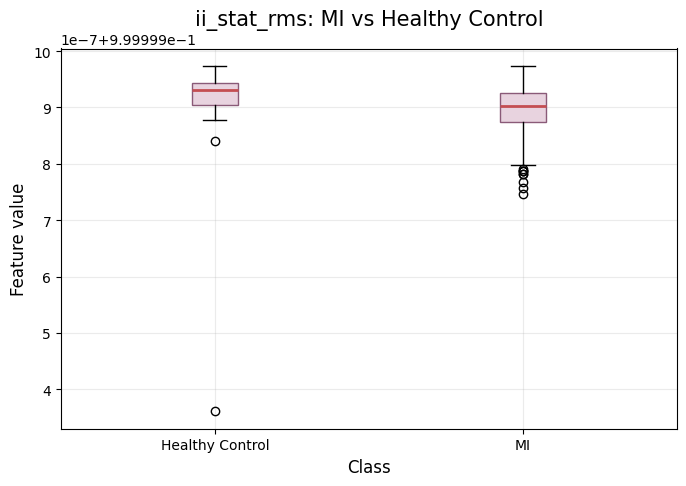

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook5_boxplot_ii_stat_rms.png


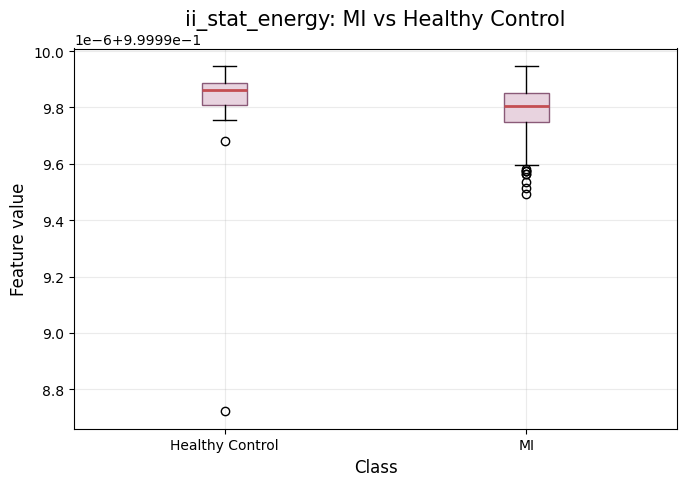

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook5_boxplot_ii_stat_energy.png


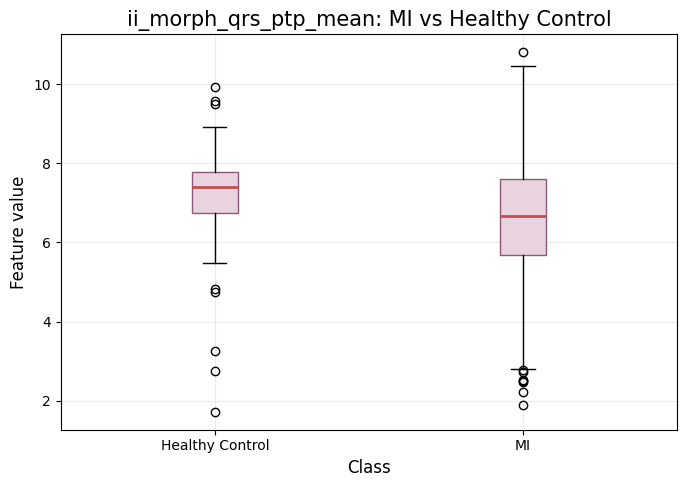

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook5_boxplot_ii_morph_qrs_ptp_mean.png


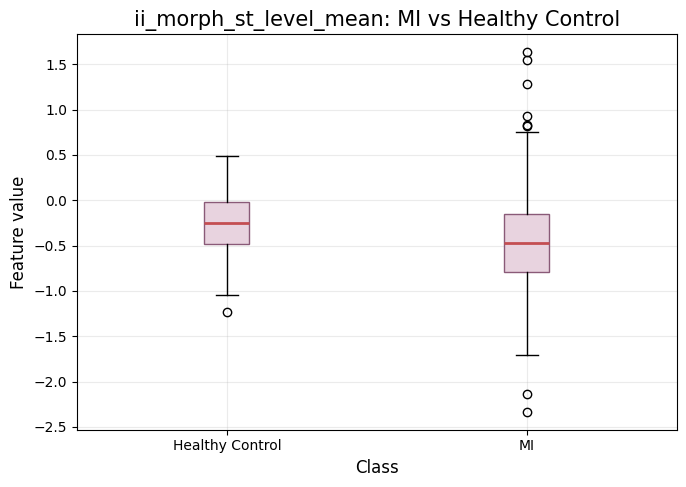

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook5_boxplot_ii_morph_st_level_mean.png


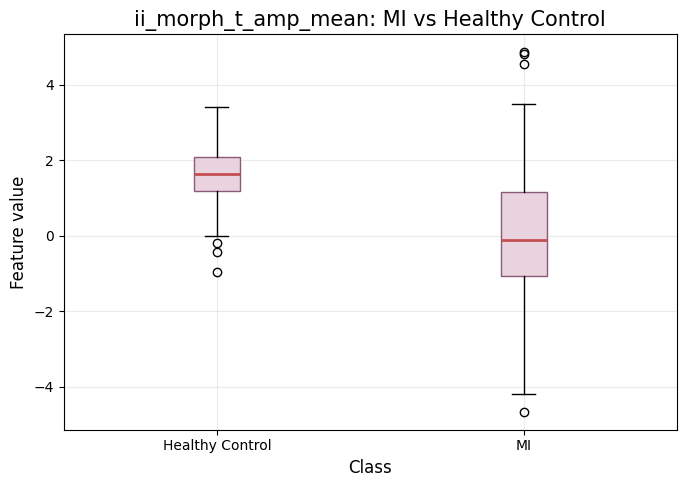

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook5_boxplot_ii_morph_t_amp_mean.png


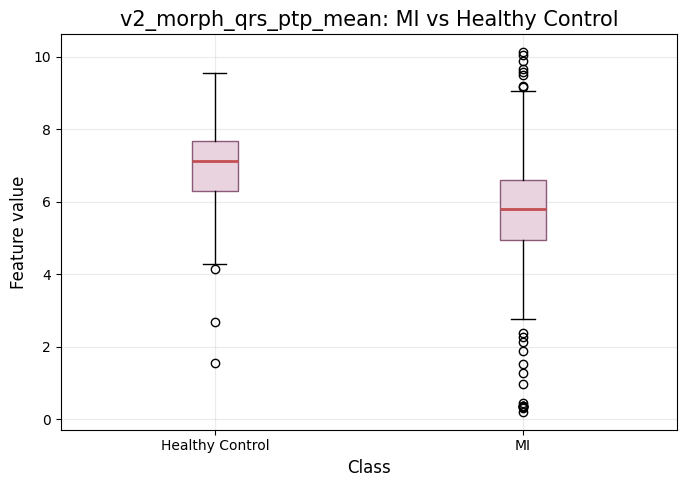

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook5_boxplot_v2_morph_qrs_ptp_mean.png


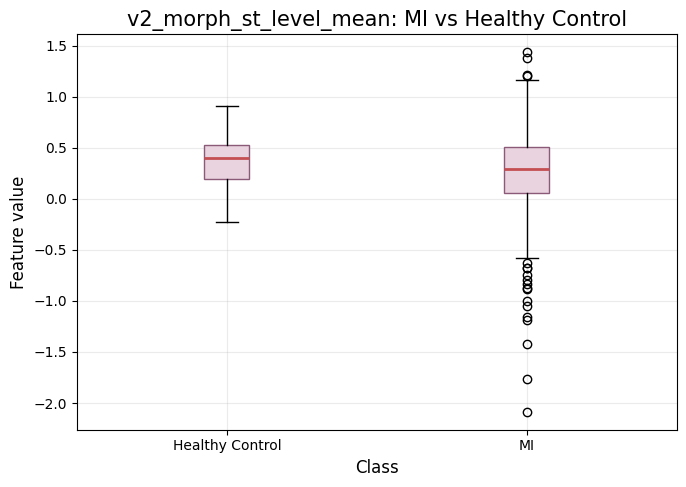

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook5_boxplot_v2_morph_st_level_mean.png


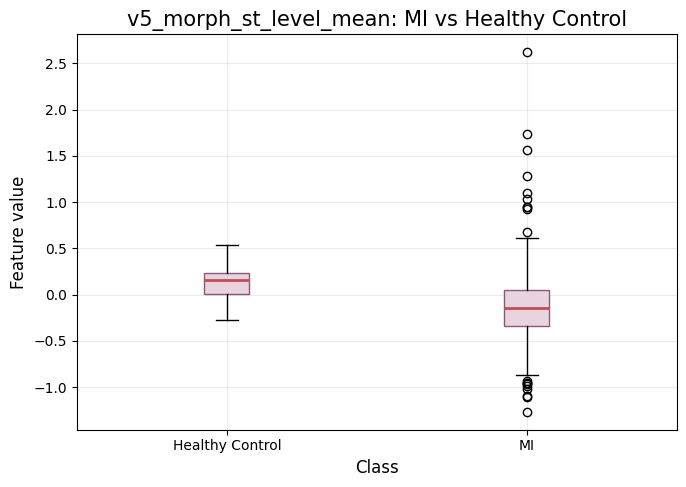

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook5_boxplot_v5_morph_st_level_mean.png


In [65]:
for feature in eda_features[:8]:
    fig_path = FIGURE_DIR / f"notebook5_boxplot_{feature}.png"

    plot_feature_boxplot_by_class(
        features_df,
        feature,
        output_path=fig_path
    )

    print("Saved:", fig_path)

In [66]:
# Cell 17
# =========================
# Compute univariate feature scores using cleaner feature set
# =========================

X_clean = features_df[clean_model_feature_cols].copy()
y = features_df["mi_detected"].astype(int).copy()

f_values, p_values = f_classif(X_clean, y)

univariate_scores_df = pd.DataFrame({
    "feature": clean_model_feature_cols,
    "f_value": f_values,
    "p_value": p_values
})

univariate_scores_df = univariate_scores_df.replace([np.inf, -np.inf], np.nan)
univariate_scores_df = univariate_scores_df.dropna(subset=["f_value"])
univariate_scores_df = univariate_scores_df.sort_values("f_value", ascending=False)

display(univariate_scores_df.head(30))

,feature,f_value,p_value
1118,limb_group_morph_t_amp_mean_mean,125.234346,8.615290e-26
955,v5_morph_t_area_min,105.285368,2.554118e-22
122,v6_stat_median,103.550438,5.192364e-22
297,iii_morph_qrs_max_amp_mean,103.344114,5.650361e-22
298,iii_morph_qrs_max_amp_median,103.173186,6.060384e-22
940,v5_morph_t_amp_min,100.581175,1.758259e-21
412,avr_morph_t_amp_mean,100.068041,2.172363e-21
1015,v6_morph_t_amp_min,98.120779,4.856407e-21
112,v5_stat_median,98.082715,4.933530e-21
937,v5_morph_t_amp_mean,95.084817,1.712667e-20


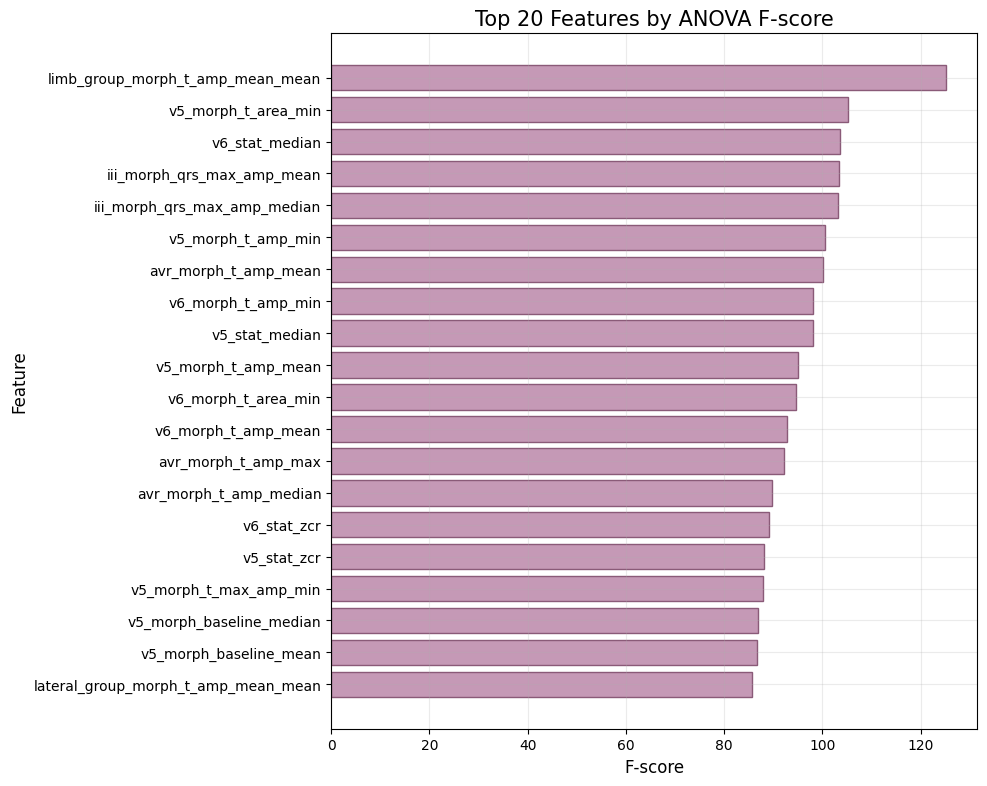

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook5_top20_univariate_features.png


In [67]:
fig_path = FIGURE_DIR / "notebook5_top20_univariate_features.png"

top_n = 20
top_features_df = univariate_scores_df.head(top_n).copy()

plt.figure(figsize=(10, 8))

plt.barh(
    top_features_df["feature"][::-1],
    top_features_df["f_value"][::-1],
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.title("Top 20 Features by ANOVA F-score")
plt.xlabel("F-score")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

In [44]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

feature_variances = np.var(X_scaled, axis=0)

variance_df = pd.DataFrame({
    "feature": numeric_model_feature_cols,
    "variance": feature_variances
}).sort_values("variance", ascending=False)

top_corr_features = univariate_scores_df.head(30)["feature"].tolist()

corr_df = features_df[top_corr_features].corr()

display(corr_df.head())

,limb_group_morph_t_amp_mean_mean,v5_morph_t_area_min,v6_stat_median,iii_morph_qrs_max_amp_mean,iii_morph_qrs_max_amp_median,v5_morph_t_amp_min,avr_morph_t_amp_mean,v6_morph_t_amp_min,v5_stat_median,v5_morph_t_amp_mean,...,v5_morph_baseline_median,v5_morph_baseline_mean,lateral_group_morph_t_amp_mean_mean,v5_morph_t_max_amp_mean,avr_morph_t_min_amp_mean,v5_morph_t_amp_median,avr_morph_t_min_amp_max,avf_morph_qrs_max_amp_median,v5_morph_t_area_median,avf_morph_qrs_max_amp_mean
limb_group_morph_t_amp_mean_mean,1.000000,0.428003,-0.487243,0.356777,0.353372,0.464270,-0.581307,0.486203,-0.400317,0.554802,...,-0.489935,-0.490064,0.399382,0.557722,-0.587259,0.536227,-0.522994,0.330185,0.418546,0.333327
v5_morph_t_area_min,0.428003,1.000000,-0.299483,0.296731,0.296128,0.459384,-0.353829,0.483095,-0.205146,0.347819,...,-0.194636,-0.204724,0.297733,0.488477,-0.381006,0.343547,-0.520801,0.249888,0.792787,0.247970
v6_stat_median,-0.487243,-0.299483,1.000000,-0.416879,-0.412689,-0.456696,0.450454,-0.535887,0.830146,-0.503676,...,0.623107,0.625641,-0.418139,-0.431265,0.416769,-0.486866,0.423571,-0.495968,-0.260022,-0.497434
iii_morph_qrs_max_amp_mean,0.356777,0.296731,-0.416879,1.000000,0.996952,0.320097,-0.236792,0.375735,-0.383359,0.254037,...,-0.325264,-0.331021,0.179908,0.206994,-0.196399,0.253352,-0.306985,0.810734,0.230497,0.811391
iii_morph_qrs_max_amp_median,0.353372,0.296128,-0.412689,0.996952,1.000000,0.318004,-0.232654,0.374494,-0.378674,0.248239,...,-0.320610,-0.327047,0.173980,0.201463,-0.191660,0.251252,-0.307111,0.809180,0.229525,0.805631


In [46]:
# =========================
# Analyze top ANOVA features by feature group
# =========================

def assign_feature_group(col):
    if col.startswith("rhythm_"):
        return "rhythm"
    elif col.startswith("contrast_"):
        return "lead_contrast"
    elif "_group_" in col:
        return "lead_group"
    elif "_morph_" in col:
        return "lead_specific_morphology"
    elif "_ratio_" in col:
        return "lead_specific_ratio"
    elif "_stat_" in col:
        return "lead_specific_statistical"
    else:
        return "other"

top_k = 50

top_feature_groups_df = univariate_scores_df.head(top_k).copy()
top_feature_groups_df["feature_group"] = top_feature_groups_df["feature"].apply(assign_feature_group)

top_group_counts = (
    top_feature_groups_df["feature_group"]
    .value_counts()
    .reset_index()
)

top_group_counts.columns = ["feature_group", "count_in_top_50"]

display(top_group_counts)

,feature_group,count_in_top_50
0,lead_specific_morphology,36
1,lead_specific_statistical,7
2,lead_group,6
3,lead_contrast,1


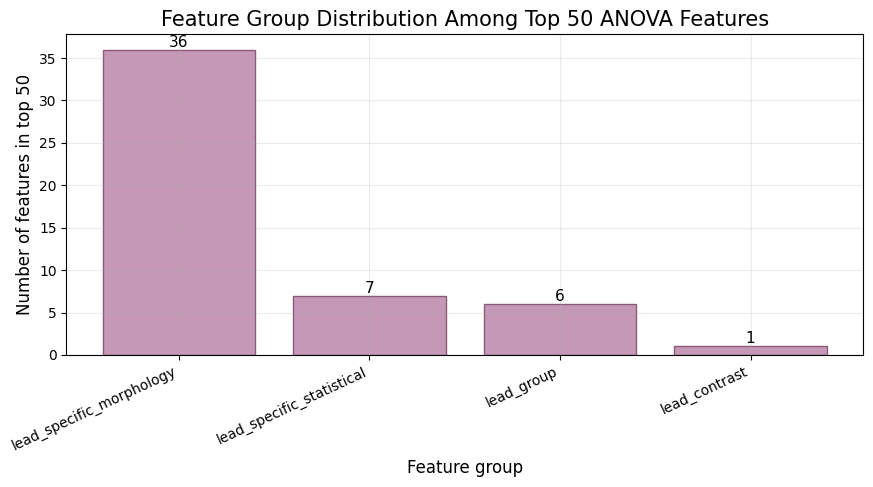

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook5_top50_feature_group_distribution.png


In [47]:
fig_path = FIGURE_DIR / "notebook5_top50_feature_group_distribution.png"

plt.figure(figsize=(9, 5))

bars = plt.bar(
    top_group_counts["feature_group"],
    top_group_counts["count_in_top_50"],
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.title("Feature Group Distribution Among Top 50 ANOVA Features")
plt.xlabel("Feature group")
plt.ylabel("Number of features in top 50")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

# PCA visualization

In [49]:
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "mi_detected": y.values
})

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)
print("Total:", pca.explained_variance_ratio_.sum())

display(pca_df.head())

Explained variance ratio:
[0.16378937 0.08595691]
Total: 0.24974628277044914


,PC1,PC2,mi_detected
0,-4.982011,-10.572348,1
1,-3.647739,-12.500463,1
2,-4.765488,-13.070298,1
3,-5.441247,-5.802715,1
4,-3.136656,8.720529,1


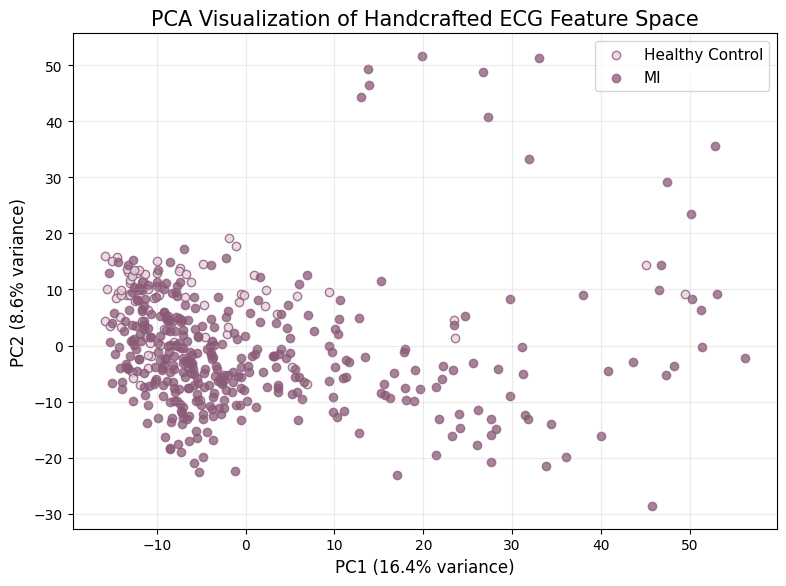

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook5_pca_feature_space.png


In [50]:
fig_path = FIGURE_DIR / "notebook5_pca_feature_space.png"

plt.figure(figsize=(8, 6))

healthy_df = pca_df[pca_df["mi_detected"] == 0]
mi_df = pca_df[pca_df["mi_detected"] == 1]

plt.scatter(
    healthy_df["PC1"],
    healthy_df["PC2"],
    color=PURPLE_LIGHT,
    edgecolor=PURPLE_DARK,
    alpha=0.8,
    label="Healthy Control"
)

plt.scatter(
    mi_df["PC1"],
    mi_df["PC2"],
    color=PURPLE_DARK,
    alpha=0.75,
    label="MI"
)

plt.title("PCA Visualization of Handcrafted ECG Feature Space")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

# Patient-wise train / validation / test split

In [51]:
patient_split_base_df = (
    features_df
    .groupby("patient_id")
    .agg(
        mi_detected=("mi_detected", lambda x: x.mode().iloc[0]),
        n_records=("record_id", "count")
    )
    .reset_index()
)

print("Patient-level table shape:", patient_split_base_df.shape)

print("\nPatient-level class distribution:")
display(patient_split_base_df["mi_detected"].value_counts())

display(patient_split_base_df.head())

Patient-level table shape: (200, 3)

Patient-level class distribution:


mi_detected
1    148
0     52
Name: count, dtype: int64

,patient_id,mi_detected,n_records
0,patient001,1,3
1,patient002,1,1
2,patient003,1,1
3,patient004,1,2
4,patient005,1,5


In [52]:
RANDOM_STATE = 42

patients = patient_split_base_df["patient_id"]
patient_labels = patient_split_base_df["mi_detected"]

train_patients, temp_patients, train_y, temp_y = train_test_split(
    patients,
    patient_labels,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=patient_labels
)

validation_patients, test_patients, validation_y, test_y = train_test_split(
    temp_patients,
    temp_y,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_y
)

patient_split_df = pd.DataFrame({
    "patient_id": patient_split_base_df["patient_id"]
})

patient_split_df["split"] = "unassigned"

patient_split_df.loc[
    patient_split_df["patient_id"].isin(train_patients),
    "split"
] = "train"

patient_split_df.loc[
    patient_split_df["patient_id"].isin(validation_patients),
    "split"
] = "validation"

patient_split_df.loc[
    patient_split_df["patient_id"].isin(test_patients),
    "split"
] = "test"

patient_split_df = patient_split_df.merge(
    patient_split_base_df,
    on="patient_id",
    how="left"
)

display(patient_split_df.head())

print("Patient split counts:")
display(patient_split_df["split"].value_counts())

,patient_id,split,mi_detected,n_records
0,patient001,train,1,3
1,patient002,test,1,1
2,patient003,train,1,1
3,patient004,test,1,2
4,patient005,train,1,5


Patient split counts:


split
train         140
test           30
validation     30
Name: count, dtype: int64

In [53]:
features_with_split_df = features_df.merge(
    patient_split_df[["patient_id", "split"]],
    on="patient_id",
    how="left"
)

print("Features with split shape:", features_with_split_df.shape)

print("\nRecord-level split counts:")
display(features_with_split_df["split"].value_counts())

print("\nAny unassigned records?")
display(features_with_split_df["split"].isna().value_counts())

Features with split shape: (448, 1423)

Record-level split counts:


split
train         308
validation     72
test           68
Name: count, dtype: int64


Any unassigned records?


split
False    448
Name: count, dtype: int64

In [54]:
print("Record-level class distribution by split:")
record_split_distribution = pd.crosstab(
    features_with_split_df["split"],
    features_with_split_df["mi_detected"]
)

display(record_split_distribution)

print("\nPatient-level class distribution by split:")
patient_split_distribution = pd.crosstab(
    patient_split_df["split"],
    patient_split_df["mi_detected"]
)

display(patient_split_distribution)

Record-level class distribution by split:


mi_detected,0,1
split,,
test,12,56
train,57,251
validation,11,61



Patient-level class distribution by split:


mi_detected,0,1
split,,
test,8,22
train,36,104
validation,8,22


In [55]:
train_set = set(patient_split_df[patient_split_df["split"] == "train"]["patient_id"])
val_set = set(patient_split_df[patient_split_df["split"] == "validation"]["patient_id"])
test_set = set(patient_split_df[patient_split_df["split"] == "test"]["patient_id"])

train_val_overlap = train_set.intersection(val_set)
train_test_overlap = train_set.intersection(test_set)
val_test_overlap = val_set.intersection(test_set)

print("Train-validation patient overlap:", len(train_val_overlap))
print("Train-test patient overlap:", len(train_test_overlap))
print("Validation-test patient overlap:", len(val_test_overlap))

if len(train_val_overlap) == 0 and len(train_test_overlap) == 0 and len(val_test_overlap) == 0:
    print("No patient leakage detected.")
else:
    print("WARNING: Patient leakage detected.")

Train-validation patient overlap: 0
Train-test patient overlap: 0
Validation-test patient overlap: 0
No patient leakage detected.


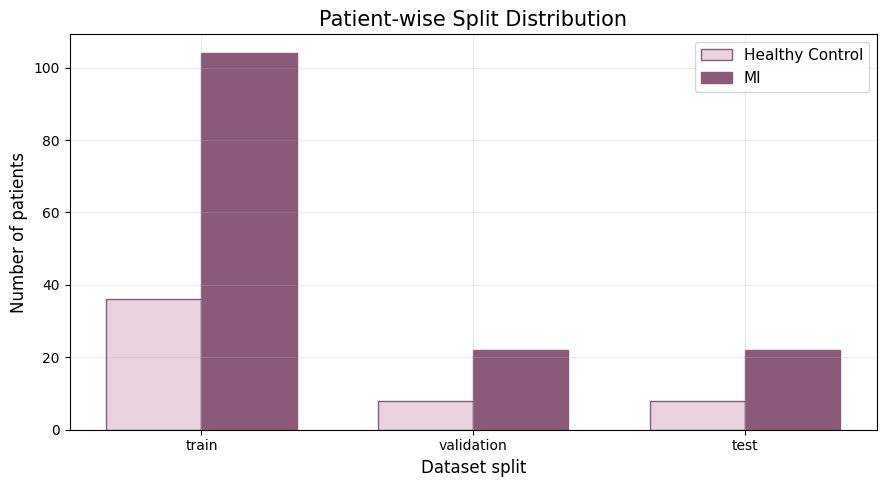

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook5_patient_wise_split_distribution.png


In [56]:
fig_path = FIGURE_DIR / "notebook5_patient_wise_split_distribution.png"

split_order = ["train", "validation", "test"]

plot_df = patient_split_distribution.reindex(split_order)

x = np.arange(len(split_order))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    plot_df.get(0, pd.Series([0, 0, 0], index=split_order)),
    width,
    label="Healthy Control",
    color=PURPLE_LIGHT,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x + width / 2,
    plot_df.get(1, pd.Series([0, 0, 0], index=split_order)),
    width,
    label="MI",
    color=PURPLE_DARK,
    edgecolor=PURPLE_DARK
)

plt.title("Patient-wise Split Distribution")
plt.xlabel("Dataset split")
plt.ylabel("Number of patients")
plt.xticks(x, split_order)
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

In [57]:
patient_split_path = PROCESSED_DIR / "patient_wise_split_detection.csv"

patient_split_df.to_csv(patient_split_path, index=False, encoding="utf-8-sig")

print("Saved patient-wise split to:")
print(patient_split_path)

Saved patient-wise split to:
d:\HUST\ET4248E - Học máy trong y tế\Final Project\data\processed\patient_wise_split_detection.csv


In [58]:
features_with_split_path = FEATURE_DIR / "ptb_detection_handcrafted_features_with_split.csv"

features_with_split_df.to_csv(features_with_split_path, index=False, encoding="utf-8-sig")

print("Saved features with split to:")
print(features_with_split_path)
print("Shape:", features_with_split_df.shape)

Saved features with split to:
d:\HUST\ET4248E - Học máy trong y tế\Final Project\data\features\ptb_detection_handcrafted_features_with_split.csv
Shape: (448, 1423)


In [59]:
feature_columns_path = TABLE_DIR / "notebook5_model_feature_columns.json"

feature_column_info = {
    "model_feature_columns": numeric_model_feature_cols,
    "excluded_columns": exclude_cols,
    "lead_specific_statistical_columns": lead_specific_stat_cols,
    "lead_specific_morphology_columns": lead_specific_morph_cols,
    "lead_specific_ratio_columns": lead_specific_ratio_cols,
    "rhythm_columns": rhythm_cols,
    "lead_group_columns": lead_group_cols,
    "lead_contrast_columns": lead_contrast_cols,
    "other_columns": other_cols
}

with open(feature_columns_path, "w", encoding="utf-8") as f:
    json.dump(feature_column_info, f, indent=4)

print("Saved model feature column information to:")
print(feature_columns_path)

Saved model feature column information to:
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook5_model_feature_columns.json


In [60]:
univariate_scores_path = TABLE_DIR / "notebook5_univariate_feature_scores.csv"
feature_group_counts_path = TABLE_DIR / "notebook5_feature_group_counts.csv"

univariate_scores_df.to_csv(univariate_scores_path, index=False, encoding="utf-8-sig")
feature_group_counts.to_csv(feature_group_counts_path, index=False, encoding="utf-8-sig")

print("Saved univariate feature scores to:")
print(univariate_scores_path)

print("Saved feature group counts to:")
print(feature_group_counts_path)

Saved univariate feature scores to:
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook5_univariate_feature_scores.csv
Saved feature group counts to:
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook5_feature_group_counts.csv


In [61]:
print("Notebook 5 completed.")

print("\nMain outputs:")
print("1.", patient_split_path)
print("2.", features_with_split_path)
print("3.", feature_columns_path)
print("4.", univariate_scores_path)
print("5.", feature_group_counts_path)

print("\nRecord-level split distribution:")
display(record_split_distribution)

print("\nPatient-level split distribution:")
display(patient_split_distribution)

print("\nModel feature matrix:")
print("Records:", features_df.shape[0])
print("Model features:", len(numeric_model_feature_cols))

Notebook 5 completed.

Main outputs:
1. d:\HUST\ET4248E - Học máy trong y tế\Final Project\data\processed\patient_wise_split_detection.csv
2. d:\HUST\ET4248E - Học máy trong y tế\Final Project\data\features\ptb_detection_handcrafted_features_with_split.csv
3. d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook5_model_feature_columns.json
4. d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook5_univariate_feature_scores.csv
5. d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook5_feature_group_counts.csv

Record-level split distribution:


mi_detected,0,1
split,,
test,12,56
train,57,251
validation,11,61



Patient-level split distribution:


mi_detected,0,1
split,,
test,8,22
train,36,104
validation,8,22



Model feature matrix:
Records: 448
Model features: 1404
